# 🌍 Global CO₂ Emissions Analysis (1900–2023)
> **Data source:** Our World in Data — Global Carbon Budget 2024  
> **Dataset:** `owid-co2-data.csv` — 1 file, 1 source, everything included  
> https://github.com/owid/co2-data

## Introduction

Climate change is one of the defining challenges of our era, and CO₂ emissions from fossil fuels remain its primary driver. This notebook provides a data-driven exploration of global CO₂ emissions from 1900 to 2023, using the **Our World in Data** dataset (Global Carbon Budget 2024) — a single, comprehensive source covering 254 countries and 79 variables.

### What This Analysis Covers

| # | Section | Key Question |
|---|---------|-------------|
| 1 | **Global Trend** | How have total emissions evolved over a century? |
| 2 | **Top Emitters** | Which countries are most responsible, and from which sources? |
| 3 | **Per-Capita vs Total** | Is total CO₂ a fair metric across countries of different sizes? |
| 4 | **CO₂ vs GDP** | Does economic growth necessarily mean more emissions? |
| 5 | **World Map** | How has the geographic distribution shifted over time? |
| 6 | **North Africa** | Where does the region stand relative to the rest of the world? |
| 7 | **Forecast 2040** | Where are we headed if current trends continue? |

### Why It Matters

The Paris Agreement targets net-zero by mid-century. Understanding *who emits*, *how much*, and *from what source* is a prerequisite for designing effective policy. This notebook goes beyond raw totals to surface fairness, efficiency, and regional context — the dimensions that make climate action politically and economically tractable.

> **Audience:** The analysis is designed to be accessible to anyone with a basic understanding of data science. Each section includes code, a chart, and a plain-language observation.


---
## Cell 1 · Setup & Data Loading

In [55]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize'    : (13, 6),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 15,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 12,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
})

# ── Load dataset (download once, reuse after) ─────────────────────────────────
URL   = 'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv'
LOCAL = 'owid-co2-data.csv'

if not os.path.exists(LOCAL):
    import urllib.request
    print('Downloading dataset...')
    urllib.request.urlretrieve(URL, LOCAL)
    print('Saved locally as owid-co2-data.csv')
else:
    print('Using local copy of owid-co2-data.csv')

df_raw = pd.read_csv(LOCAL)

print(f'\nShape   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Years   : {df_raw.year.min()} → {df_raw.year.max()}')
print(f'Entries : {df_raw.country.nunique()} countries / regions')
df_raw[df_raw['year'] == 2022].iloc[20:31]

Using local copy of owid-co2-data.csv

Shape   : 50,411 rows × 79 columns
Years   : 1750 → 2024
Entries : 254 countries / regions


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
4512,Bahrain,2022,BHR,1533460.0,5.876976e+10,0.323,0.211,37.827,1.562,4.306,...,NaN,0.087,0.001,0.000,0.001,0.000,62.006,61.962,-19.000,-50.230
4787,Bangladesh,2022,BGD,169384891.0,8.581439e+11,1.416,0.008,102.147,3.617,3.671,...,NaN,0.375,0.003,0.002,0.006,0.001,228.957,129.448,64.025,62.679
5062,Barbados,2022,BRB,282324.0,3.408006e+09,0.106,0.375,1.315,0.125,10.492,...,NaN,0.002,0.000,0.000,0.000,0.000,1.489,1.463,NaN,NaN
5241,Belarus,2022,BLR,9173240.0,1.757738e+11,2.279,0.248,57.121,-3.741,-6.146,...,0.225,0.344,0.001,0.004,0.006,0.001,96.007,67.391,11.207,19.621
5437,Belgium,2022,BEL,11641814.0,4.896784e+11,2.456,0.211,88.915,-6.013,-6.334,...,0.422,0.412,0.000,0.006,0.007,0.000,111.423,100.224,118.183,132.917
5612,Belize,2022,BLZ,402741.0,NaN,0.000,0.000,0.724,0.030,4.344,...,NaN,0.013,0.000,0.000,0.000,0.000,6.780,1.062,NaN,NaN
5787,Benin,2022,BEN,13759507.0,3.329036e+10,0.465,0.034,6.092,0.286,4.935,...,NaN,0.046,0.000,0.000,0.001,0.000,40.322,10.323,2.504,41.106
5961,Bermuda,2022,BMU,64772.0,NaN,0.000,0.000,0.531,0.014,2.730,...,NaN,0.001,NaN,0.000,0.000,NaN,NaN,NaN,NaN,NaN
6236,Bhutan,2022,BTN,780921.0,NaN,0.314,0.402,1.550,0.095,6.525,...,NaN,0.030,0.000,0.000,0.000,0.000,9.444,2.408,NaN,NaN
6511,Bolivia,2022,BOL,12077156.0,7.816531e+10,1.548,0.128,23.488,1.722,7.909,...,NaN,0.277,0.001,0.003,0.005,0.000,144.386,28.204,0.590,2.510


---
## Cell 2 · Cleaning & Filtering

**Rules:**
- Keep only real countries → rows where `iso_code` exists (OWID aggregates like "World" or "Asia" have no ISO code)
- Keep years ≥ 1900 (earlier data is too sparse)
- Select only the columns we use — no noise
- Report missing values transparently

In [56]:
# ── Keep real countries only ──────────────────────────────────────────────────
df = (
    df_raw
    .query('iso_code.notna() and year >= 1900')
    .copy()
)

# ── Select columns we need ────────────────────────────────────────────────────
COLS = [
    'country', 'iso_code', 'year',
    'co2',                   # total CO₂ (Mt)
    'co2_per_capita',        # tonnes / person
    'co2_per_gdp',           # kg per $ of GDP
    'coal_co2',              # source breakdown
    'oil_co2',
    'gas_co2',
    'cement_co2',
    'land_use_change_co2',
    'population',
    'gdp',
    'energy_per_capita',
]
df = df[COLS]

# ── Missing value report ──────────────────────────────────────────────────────
missing = df.isnull().mean().mul(100).round(1)
print('Missing values per column (%):')
print(missing[missing > 0].to_string())

# ── Key insight: gdp column is missing after ~2019, use co2_per_gdp instead ──
gdp_years = df.dropna(subset=['gdp']).year
print(f'\ngdp column available : {gdp_years.min()} – {gdp_years.max()}')
print(f'co2_per_gdp available: {df.dropna(subset=["co2_per_gdp"]).year.min()} – {df.dropna(subset=["co2_per_gdp"]).year.max()}')

print(f'\nFinal dataset : {df.shape[0]:,} rows, {df.country.nunique()} countries')

Missing values per column (%):
co2                    27.4
co2_per_capita         28.2
co2_per_gdp            50.8
coal_co2               45.3
oil_co2                30.4
gas_co2                57.0
cement_co2             31.3
land_use_change_co2     9.6
population              4.3
gdp                    49.5
energy_per_capita      64.3

gdp column available : 1900 – 2022
co2_per_gdp available: 1900 – 2022

Final dataset : 27,250 rows, 218 countries


---
## Cell 3 · Global Trend — The Big Picture

Sum all countries per year. Annotate historical events that caused visible drops or acceleration.

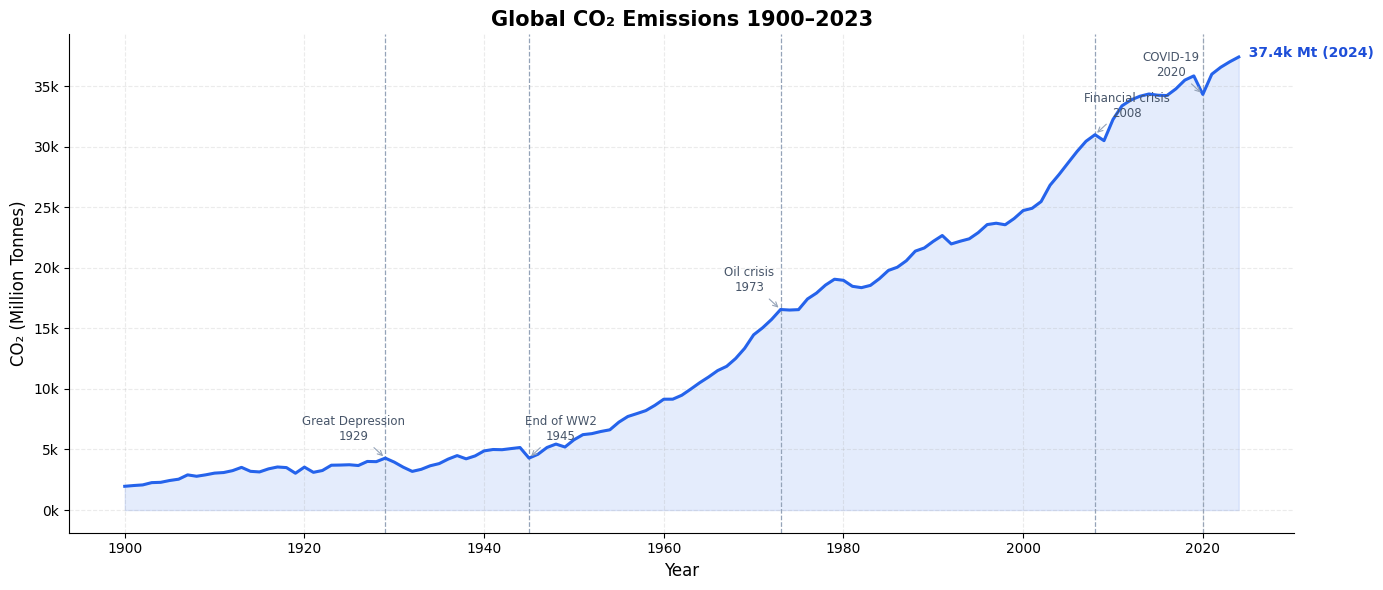

Peak year  : 2024
Peak value : 37,398 Mt
Growth since 1900 : ×19.1


In [57]:
# ── World total CO₂ per year ──────────────────────────────────────────────────
world = (
    df.groupby('year')['co2']
    .sum()
    .reset_index()
    .rename(columns={'co2': 'total_co2'})
)

EVENTS = {
    1929: ('Great Depression\n1929', -3.5),
    1945: ('End of WW2\n1945',       +3.5),
    1973: ('Oil crisis\n1973',        -3.5),
    2008: ('Financial crisis\n2008',  +3.5),
    2020: ('COVID-19\n2020',          -3.5),
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(world.year, world.total_co2, alpha=0.12, color='#2563EB')
ax.plot(world.year, world.total_co2, color='#2563EB', linewidth=2.2, zorder=3)

for yr, (label, offset) in EVENTS.items():
    y_val = world.loc[world.year == yr, 'total_co2'].values
    if len(y_val):
        ax.axvline(yr, color='#94A3B8', linewidth=0.9, linestyle='--', zorder=1)
        ax.annotate(
            label,
            xy=(yr, y_val[0]),
            xytext=(yr + offset, y_val[0] + 1500),
            fontsize=8.5, color='#475569',
            arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=0.8),
            ha='center'
        )

# Latest value callout
latest = world.iloc[-1]
ax.annotate(
    f"  {latest.total_co2/1000:.1f}k Mt ({int(latest.year)})",
    xy=(latest.year, latest.total_co2),
    fontsize=10, fontweight='bold', color='#1D4ED8'
)

ax.set_title('Global CO₂ Emissions 1900–2023')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (Million Tonnes)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

print(f"Peak year  : {world.loc[world.total_co2.idxmax(), 'year']}")
print(f"Peak value : {world.total_co2.max():,.0f} Mt")
print(f"Growth since 1900 : ×{world.total_co2.max() / world.iloc[0].total_co2:.1f}")


> **Observation:** Emissions grew nearly uninterrupted for over a century. Every crisis caused a temporary dip, but the trend always resumed — confirming that without structural change, growth in CO₂ is the default outcome.

---
## Cell 4 · Top Emitters — Who Is Responsible?

Stacked bars by source (coal / oil / gas / cement). Values printed on each bar.

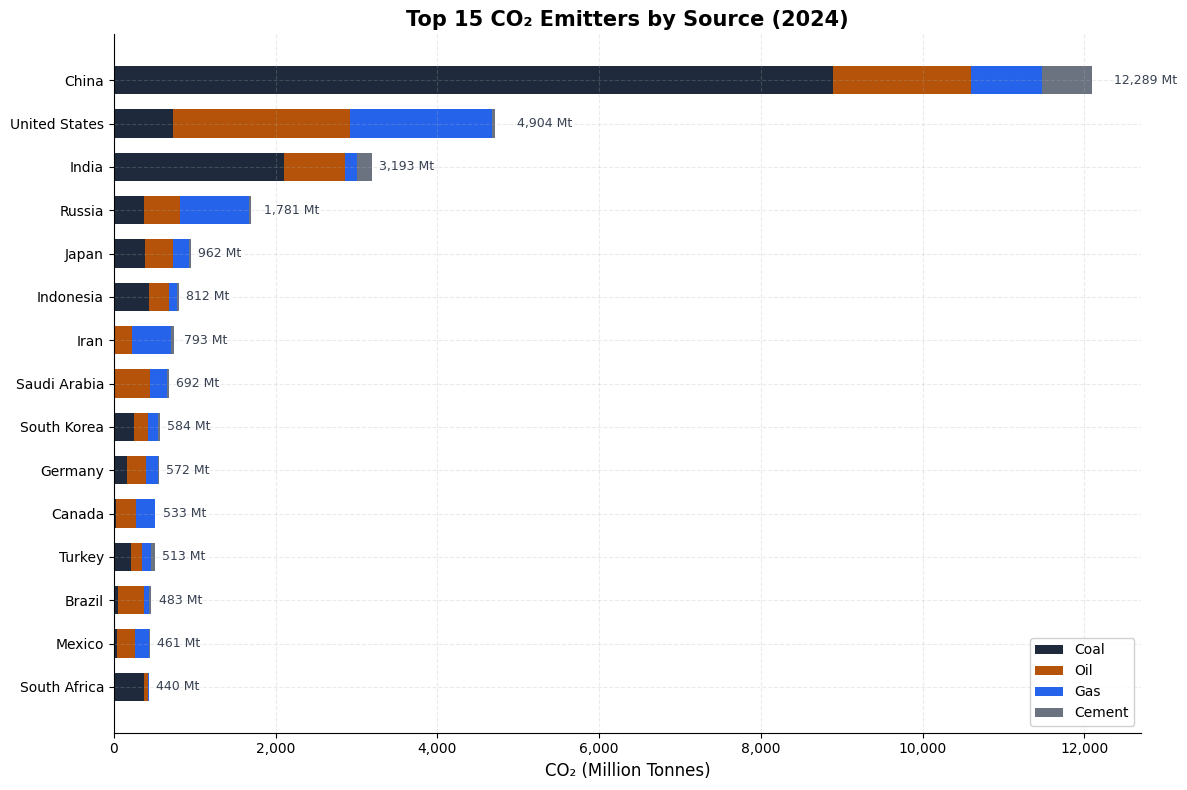

Top 5  countries = 61.8% of global emissions
Top 15 countries = 77.6% of global emissions


In [58]:
# Most recent year with good coverage
LATEST = df.dropna(subset=['co2']).year.max()

top = (
    df[df.year == LATEST]
    .dropna(subset=['co2'])
    .sort_values('co2', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

SOURCES = ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']
LABELS  = ['Coal', 'Oil', 'Gas', 'Cement']
COLORS  = ['#1E293B', '#B45309', '#2563EB', '#6B7280']

fig, ax = plt.subplots(figsize=(12, 8))
left = np.zeros(len(top))

for col, label, color in zip(SOURCES, LABELS, COLORS):
    vals = top[col].fillna(0).values
    ax.barh(top.country, vals, left=left, label=label, color=color, height=0.65)
    left += vals

# Print total value at end of each bar
for i, (_, row) in enumerate(top.iterrows()):
    ax.text(row.co2 + 80, i, f'{row.co2:,.0f} Mt',
            va='center', fontsize=9, color='#374151')

ax.invert_yaxis()
ax.set_title(f'Top 15 CO₂ Emitters by Source ({LATEST})')
ax.set_xlabel('CO₂ (Million Tonnes)')
ax.legend(loc='lower right', framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

total_world = df[df.year == LATEST].co2.sum()
print(f'Top 5  countries = {top.head(5).co2.sum() / total_world * 100:.1f}% of global emissions')
print(f'Top 15 countries = {top.head(15).co2.sum() / total_world * 100:.1f}% of global emissions')

> **Observation:** A handful of countries drive almost all global emissions. China's dominance via coal and the USA's via oil/gas show that the source mix — not just the total — determines how hard decarbonisation will be.

---
## Cell 5 · Per-Capita vs Total — The Fairness Question

A country of 1.4 billion always looks worse in total. Per capita is the fair metric.

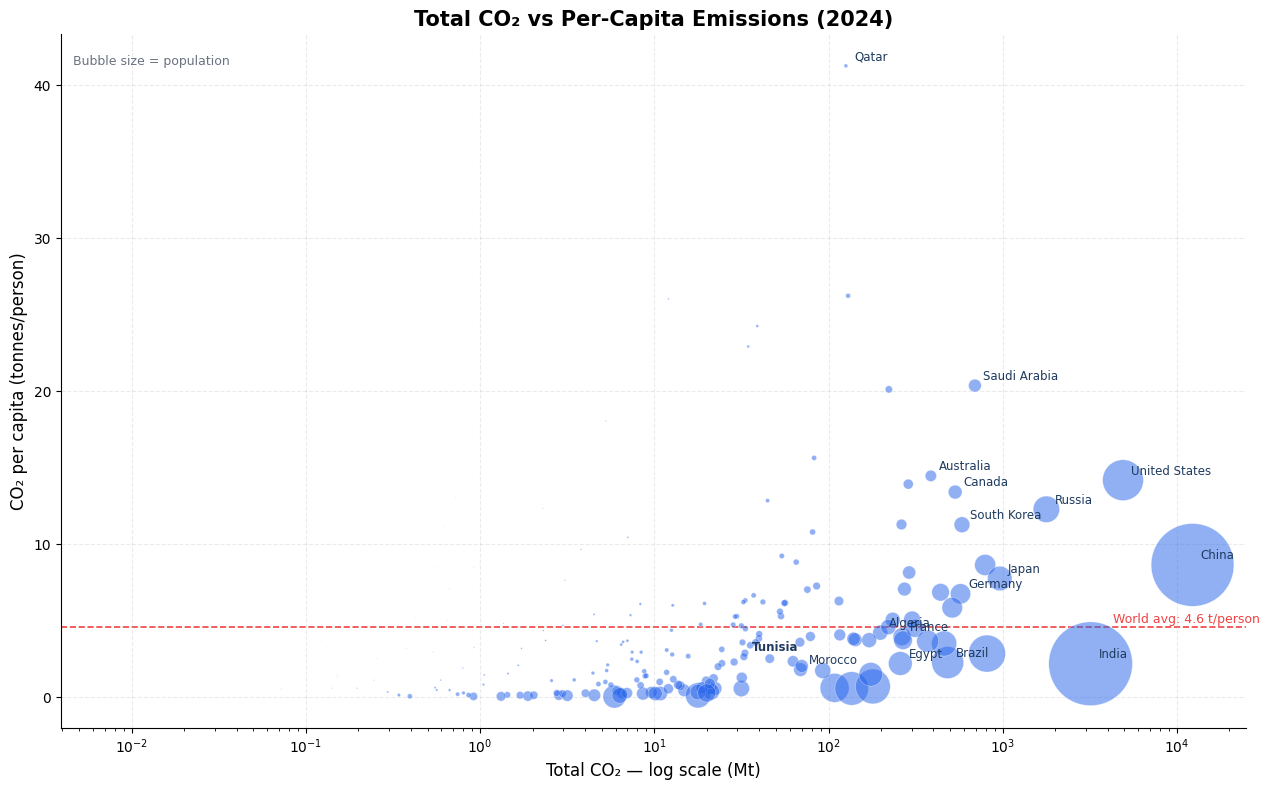

In [59]:
# Use most recent year with good per-capita coverage
LATEST_PC = df.dropna(subset=['co2', 'co2_per_capita', 'population']).year.max()

scatter_df = (
    df[(df.year == LATEST_PC)]
    .dropna(subset=['co2', 'co2_per_capita', 'population'])
)

LABEL_COUNTRIES = [
    'China', 'United States', 'India', 'Russia', 'Germany',
    'Saudi Arabia', 'Qatar', 'Canada', 'Australia',
    'Tunisia', 'Algeria', 'Morocco', 'Egypt',
    'Brazil', 'Japan', 'South Korea', 'France',
]

fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(
    scatter_df.co2,
    scatter_df.co2_per_capita,
    s=scatter_df.population / 4e5,
    alpha=0.5,
    color='#2563EB',
    edgecolors='white',
    linewidth=0.4,
    zorder=2
)

for _, row in scatter_df[scatter_df.country.isin(LABEL_COUNTRIES)].iterrows():
    ax.annotate(
        row.country,
        xy=(row.co2, row.co2_per_capita),
        xytext=(6, 4), textcoords='offset points',
        fontsize=8.5, color='#1E3A5F',
        fontweight='bold' if row.country == 'Tunisia' else 'normal'
    )

# World average reference line
avg_pc = scatter_df.co2_per_capita.mean()
ax.axhline(avg_pc, color='#EF4444', linewidth=1.2, linestyle='--', zorder=1)
ax.text(scatter_df.co2.max() * 0.35, avg_pc + 0.2,
        f'World avg: {avg_pc:.1f} t/person', color='#EF4444', fontsize=9)

ax.set_xscale('log')
ax.set_title(f'Total CO₂ vs Per-Capita Emissions ({LATEST_PC})')
ax.set_xlabel('Total CO₂ — log scale (Mt)')
ax.set_ylabel('CO₂ per capita (tonnes/person)')
ax.text(0.01, 0.97, 'Bubble size = population',
        transform=ax.transAxes, fontsize=9, color='#6B7280', va='top')
plt.tight_layout()
plt.show()

> **Observation:** Total emissions are a misleading fairness metric. Gulf states and the USA emit far more per person than China or India. North African countries sit below the world average — they contribute little to the problem yet face severe climate impacts.

---
## Cell 6 · CO₂ vs GDP — Does Wealth Always Mean More Emissions?

We use `co2_per_gdp` (already in the dataset, well populated) vs `co2_per_capita`.  
We pick the most recent year that has at least 80 countries with data — no empty charts.

Year used : 2022  |  Countries : 164


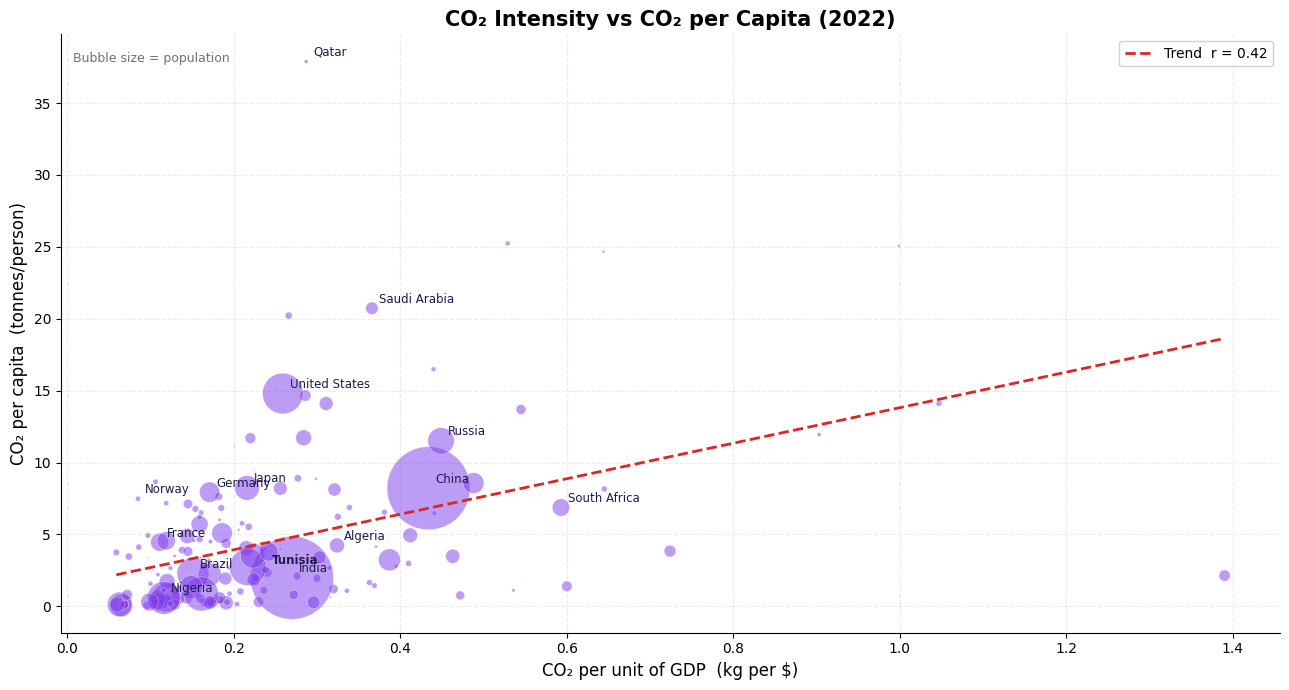

Correlation: r = 0.416  (p = 3.05e-08)
→ Countries that burn more CO₂ per dollar of GDP also emit more per person.


In [60]:
# ── Find best year: most recent with ≥80 countries having both columns ────────
gdp_counts = (
    df.dropna(subset=['co2_per_gdp', 'co2_per_capita', 'population'])
    .groupby('year')['country']
    .count()
)
BEST_YEAR = gdp_counts[gdp_counts >= 80].index.max()

gdp_df = (
    df[(df.year == BEST_YEAR)]
    .dropna(subset=['co2_per_gdp', 'co2_per_capita', 'population'])
    .query('co2_per_gdp > 0 and co2_per_capita > 0')
)
print(f'Year used : {BEST_YEAR}  |  Countries : {len(gdp_df)}')

fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(
    gdp_df.co2_per_gdp,
    gdp_df.co2_per_capita,
    s=gdp_df.population / 4e5,
    alpha=0.5,
    color='#7C3AED',
    edgecolors='white',
    linewidth=0.4,
    zorder=2
)

# Regression line
slope, intercept, r, p, _ = stats.linregress(gdp_df.co2_per_gdp, gdp_df.co2_per_capita)
x_range = np.linspace(gdp_df.co2_per_gdp.min(), gdp_df.co2_per_gdp.max(), 200)
ax.plot(x_range, slope * x_range + intercept,
        color='#DC2626', linewidth=2, linestyle='--',
        label=f'Trend  r = {r:.2f}', zorder=3)

# Labels
GDPLABELS = ['Qatar', 'United States', 'Germany', 'China', 'India',
             'Tunisia', 'Algeria', 'Norway', 'Japan', 'Saudi Arabia',
             'Nigeria', 'France', 'Brazil', 'South Africa', 'Russia']
for _, row in gdp_df[gdp_df.country.isin(GDPLABELS)].iterrows():
    ax.annotate(
        row.country,
        xy=(row.co2_per_gdp, row.co2_per_capita),
        xytext=(5, 4), textcoords='offset points',
        fontsize=8.5, color='#1E1B4B',
        fontweight='bold' if row.country == 'Tunisia' else 'normal'
    )

ax.set_title(f'CO₂ Intensity vs CO₂ per Capita ({BEST_YEAR})')
ax.set_xlabel('CO₂ per unit of GDP  (kg per $)')
ax.set_ylabel('CO₂ per capita  (tonnes/person)')
ax.legend(framealpha=0.9)
ax.text(0.01, 0.97, 'Bubble size = population',
        transform=ax.transAxes, fontsize=9, color='#6B7280', va='top')
plt.tight_layout()
plt.show()

print(f'Correlation: r = {r:.3f}  (p = {p:.2e})')
print('→ Countries that burn more CO₂ per dollar of GDP also emit more per person.')

> **Observation:** Countries with high CO₂ per unit of GDP also emit more per capita — inefficiency compounds at every level. Meanwhile, Germany and Japan prove that economic growth and low carbon intensity can coexist.

---
## Cell 7 · Dynamic World Map — CO₂ Emissions by Country

Interactive animated choropleth: drag the year slider or press **Play** to watch emissions evolve across the globe.  
Hover any country to see its exact figures.

In [61]:
try:
    import plotly.express as px
    import plotly.graph_objects as go
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly', '-q'])
    import plotly.express as px
    import plotly.graph_objects as go

# ── Prepare data: every 5th year from 1950 onward ────────────────────────────
map_df = (
    df[df.year >= 1950]
    .dropna(subset=['co2', 'iso_code'])
    .copy()
)
map_df['year_str']     = map_df['year'].astype(str)
map_df['co2_log']      = np.log10(map_df['co2'].clip(lower=0.01))
map_df['co2_round']    = map_df['co2'].round(1)
map_df['co2_pc_round'] = map_df['co2_per_capita'].round(2)

years_to_show = [y for y in sorted(map_df['year'].unique()) if y % 5 == 0]
map_df = map_df[map_df['year'].isin(years_to_show)]

# ── Pre-compute peak emitter per year ────────────────────────────────────────
peak_per_year = (
    map_df.groupby('year')
    .apply(lambda g: g.loc[g['co2'].idxmax(), ['country', 'co2_round']])
    .reset_index()
)

def peak_annotation(year):
    row = peak_per_year[peak_per_year['year'] == year].iloc[0]
    return dict(
        x=0.01, y=0.12,
        xref='paper', yref='paper',
        xanchor='left', yanchor='bottom',
        text=(
            f"<b>Peak emitter</b><br>"
            f"🏭 <b>{row['country']}</b><br>"
            f"📊 {row['co2_round']:,.0f} Mt"
        ),
        showarrow=False,
        font=dict(size=13, color='#1E3A8A'),
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#2563EB',
        borderwidth=1.5,
        borderpad=6,
    )

# ── Build choropleth ──────────────────────────────────────────────────────────
fig = px.choropleth(
    map_df,
    locations='iso_code',
    color='co2_log',
    hover_name='country',
    hover_data={
        'co2_round'    : True,
        'co2_pc_round' : True,
        'year_str'     : True,
        'iso_code'     : False,
        'co2_log'      : False,
    },
    animation_frame='year_str',
    color_continuous_scale='Reds',
    range_color=[
        map_df['co2_log'].quantile(0.05),
        map_df['co2_log'].quantile(0.98),
    ],
    title='🌍 Global CO₂ Emissions by Country (1950 – 2023)',
    labels={
        'co2_log'      : 'CO₂ log₁₀(Mt)',
        'co2_round'    : 'Total CO₂ (Mt)',
        'co2_pc_round' : 'CO₂ per capita (t/person)',
        'year_str'     : 'Year',
    },
    projection='natural earth',
    height=620,
)

# ── Inject per-frame peak annotation ─────────────────────────────────────────
for frame in fig.frames:
    yr = int(frame.name)
    frame.layout = go.Layout(annotations=[peak_annotation(yr)])

fig.update_layout(annotations=[peak_annotation(years_to_show[0])])
fig.update_layout(
    coloraxis_colorbar=dict(
        title='CO₂ (Mt)<br><i>log scale</i>',
        tickvals=[0, 1, 2, 3, 4],
        ticktext=['1', '10', '100', '1 000', '10 000'],
    ),
    title_font_size=18,
    margin=dict(l=0, r=0, t=60, b=0),
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor='#94A3B8'),
    updatemenus=[dict(
        type='buttons', showactive=False, y=0, x=0.5, xanchor='center',
        buttons=[
            dict(label='▶  Play',  method='animate',
                 args=[None, dict(frame=dict(duration=400, redraw=True), fromcurrent=True)]),
            dict(label='⏸  Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
        ],
    )],
)

fig.show()
print('Tip: hover any country for exact figures. The blue badge updates with the peak emitter each year.')


Tip: hover any country for exact figures. The blue badge updates with the peak emitter each year.


> **Observation:** The map makes the shift of emissions from West to East unmistakable. Africa remains nearly invisible despite its population size — a stark illustration of the gap between who causes climate change and who suffers from it.

---
## Cell 8 · Tunisia & North Africa

Regional comparison: Tunisia vs Algeria, Morocco, Egypt.  
Two panels: total CO₂ and per capita, with peak markers (★) and world average as reference.

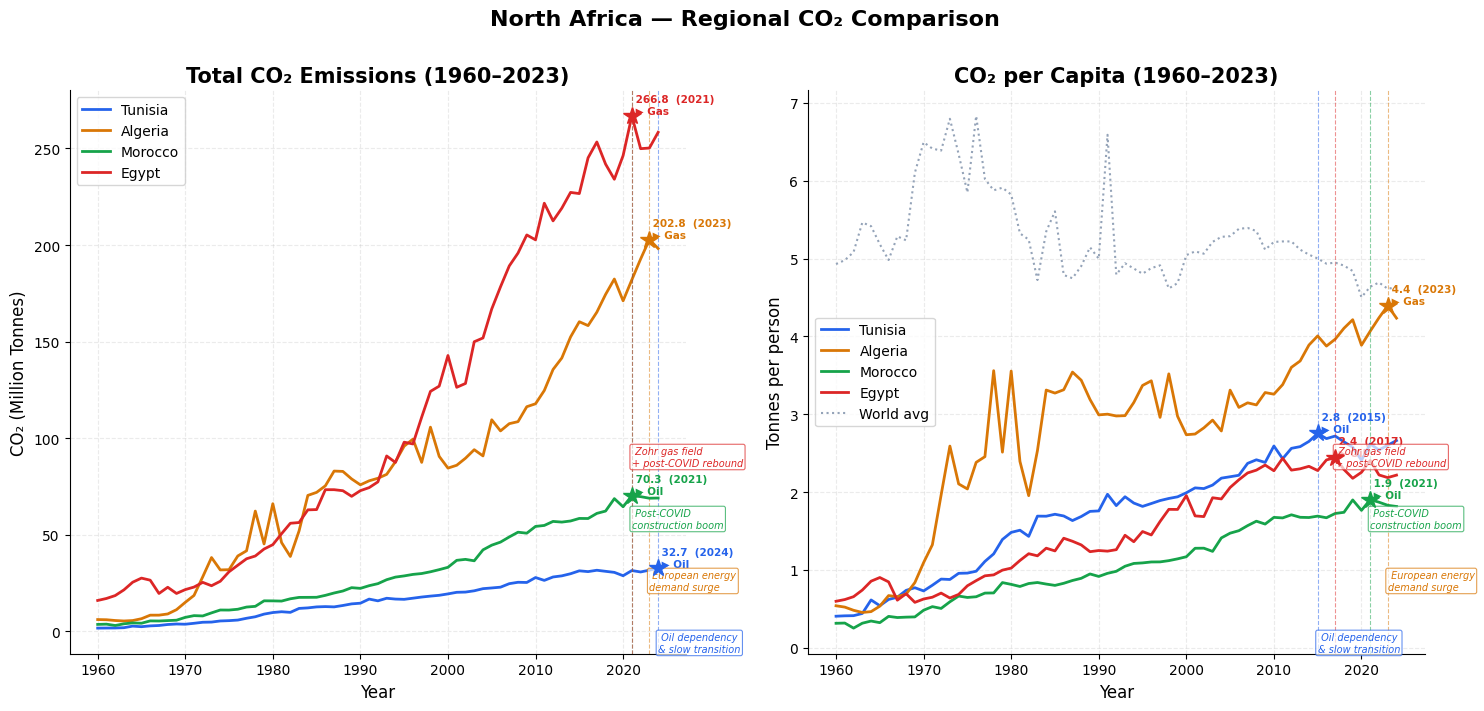


── North Africa in 2024 ──
         Total CO₂ (Mt)  CO₂/person (t)  Population (M)
country                                                
Algeria          198.20            4.23            46.8
Egypt            258.37            2.22           116.5
Morocco           69.06            1.81            38.1
Tunisia           32.66            2.66            12.3


In [62]:
NORTH_AFRICA = ['Tunisia', 'Algeria', 'Morocco', 'Egypt']
COLORS_NA    = ['#2563EB', '#D97706', '#16A34A', '#DC2626']

SOURCES = {
    'oil_co2'    : 'Oil',
    'gas_co2'    : 'Gas',
    'coal_co2'   : 'Coal',
    'cement_co2' : 'Cement',
}

PEAK_CAUSES = {
    'Tunisia' : 'Oil dependency\n& slow transition',
    'Algeria' : 'European energy\ndemand surge',
    'Morocco' : 'Post-COVID\nconstruction boom',
    'Egypt'   : 'Zohr gas field\n+ post-COVID rebound',
}

na_df = df[df.country.isin(NORTH_AFRICA) & df.year.ge(1960)]

def dominant_source(country, year):
    row = na_df[(na_df.country == country) & (na_df.year == year)].iloc[0]
    vals = {label: row.get(col, 0) or 0 for col, label in SOURCES.items()}
    return max(vals, key=vals.get)

def mark_peak(ax, sub, col, color, country, idx=0):
    peak_idx = sub[col].idxmax()
    peak_yr  = sub.loc[peak_idx, 'year']
    peak_val = sub.loc[peak_idx, col]
    src      = dominant_source(country, peak_yr)
    cause    = PEAK_CAUSES.get(country, '')

    ax.axvline(peak_yr, color=color, linewidth=0.8, linestyle='--', alpha=0.5)
    ax.plot(peak_yr, peak_val, marker='*', markersize=13,
            color=color, zorder=5, linestyle='None')

    ax.text(
        peak_yr, peak_val,
        f' {peak_val:.1f}  ({int(peak_yr)})\n ▶ {src}',
        fontsize=7.5, color=color, va='bottom', fontweight='bold',
    )
    # Stagger each country's box vertically using axes fraction (0=bottom, 1=top)
    ax.text(
        peak_yr, idx * 0.11,
        f' {cause}',
        fontsize=7, color=color, va='bottom', ha='left',
        style='italic',
        transform=ax.get_xaxis_transform(),
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.7, lw=0.8),
    )

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── Left: total CO₂ ───────────────────────────────────────────────────────────
for i, (country, color) in enumerate(zip(NORTH_AFRICA, COLORS_NA)):
    sub = na_df[na_df.country == country].dropna(subset=['co2'])
    axes[0].plot(sub.year, sub.co2, label=country, color=color, linewidth=2)
    mark_peak(axes[0], sub, 'co2', color, country, idx=i)

axes[0].set_title('Total CO₂ Emissions (1960–2023)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('CO₂ (Million Tonnes)')
axes[0].legend()

# ── Right: per capita + world average ────────────────────────────────────────
for i, (country, color) in enumerate(zip(NORTH_AFRICA, COLORS_NA)):
    sub = na_df[na_df.country == country].dropna(subset=['co2_per_capita'])
    axes[1].plot(sub.year, sub.co2_per_capita, label=country, color=color, linewidth=2)
    mark_peak(axes[1], sub, 'co2_per_capita', color, country, idx=i)

world_avg = (
    df[df.year.ge(1960)]
    .groupby('year')['co2_per_capita']
    .mean()
    .reset_index()
)
axes[1].plot(world_avg.year, world_avg.co2_per_capita,
             color='#94A3B8', linewidth=1.5, linestyle=':', label='World avg')
axes[1].set_title('CO₂ per Capita (1960–2023)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Tonnes per person')
axes[1].legend()

plt.suptitle('North Africa — Regional CO₂ Comparison',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
LATEST_NA = df[df.country.isin(NORTH_AFRICA)].dropna(subset=['co2']).year.max()
table = (
    df[(df.country.isin(NORTH_AFRICA)) & (df.year == LATEST_NA)]
    [['country', 'co2', 'co2_per_capita', 'population']]
    .assign(population_M=lambda x: (x.population / 1e6).round(1))
    .drop(columns='population')
    .rename(columns={
        'co2'           : 'Total CO₂ (Mt)',
        'co2_per_capita': 'CO₂/person (t)',
        'population_M'  : 'Population (M)'
    })
    .set_index('country')
    .round(2)
)
print(f'\n── North Africa in {LATEST_NA} ──')
print(table.to_string())

> **Observation:** All four North African countries remain below the world per-capita average. Egypt's rapid rise since 2015 (Zohr gas field) and Algeria's gas-export economy show that regional growth is still fossil-fuel driven — the window to build a renewable alternative is now.

---
## Cell 9 · Forecast 2024–2040

Linear trend on post-1990 global data. 95% confidence interval included.  
Simple, explainable, and honest about its limits.

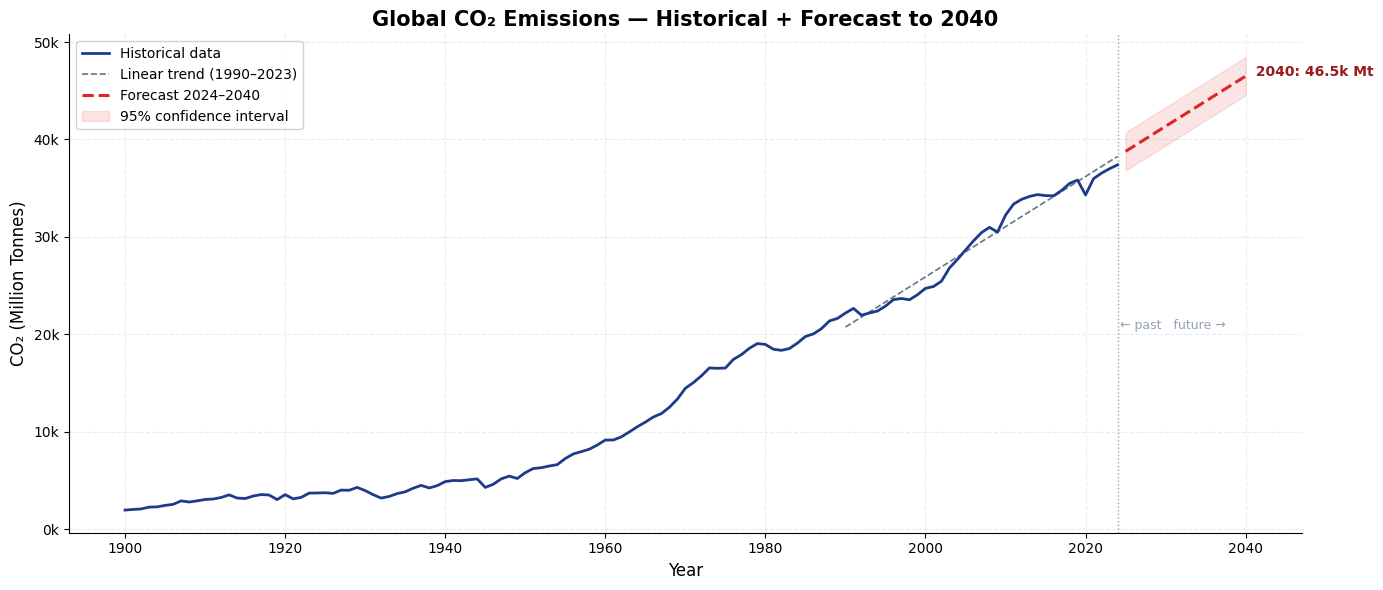

── Forecast summary ──
Trend slope    : +515 Mt / year
2030 projection: 41.4k Mt
2040 projection: 46.5k Mt
Change vs 2024   : +9.1k Mt  (24.4%)

Note: simple linear extrapolation — assumes current growth continues.
Does not account for climate policy, renewables, or economic shocks.


In [63]:
# Post-1990 world totals
world_mod = world[world.year >= 1990].dropna()
x = world_mod.year.values
y = world_mod.total_co2.values

# Linear regression
slope, intercept, r, p, se = stats.linregress(x, y)

# Forecast 2024–2040
LAST_YEAR    = int(world_mod.year.max())
future_years = np.arange(LAST_YEAR + 1, 2041)
forecast     = slope * future_years + intercept

# 95% confidence band
residuals = y - (slope * x + intercept)
std_err   = residuals.std()
ci_upper  = forecast + 1.96 * std_err
ci_lower  = forecast - 1.96 * std_err

fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(world.year, world.total_co2,
        color='#1E3A8A', linewidth=2, label='Historical data', zorder=3)

# Trend on historical
ax.plot(x, slope * x + intercept,
        color='#64748B', linewidth=1.2, linestyle='--',
        label='Linear trend (1990–2023)', zorder=2)

# Forecast + confidence band
ax.plot(future_years, forecast,
        color='#DC2626', linewidth=2.2, linestyle='--',
        label='Forecast 2024–2040', zorder=3)
ax.fill_between(future_years, ci_lower, ci_upper,
                color='#DC2626', alpha=0.12, label='95% confidence interval')

# Divider
ax.axvline(LAST_YEAR, color='#94A3B8', linewidth=1, linestyle=':')
ax.text(LAST_YEAR + 0.3, y.max() * 0.55,
        '← past   future →', color='#94A3B8', fontsize=9)

# 2040 callout
ax.annotate(
    f'  2040: {forecast[-1]/1000:.1f}k Mt',
    xy=(2040, forecast[-1]),
    fontsize=10, fontweight='bold', color='#991B1B'
)

ax.set_title('Global CO₂ Emissions — Historical + Forecast to 2040')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (Million Tonnes)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

print('── Forecast summary ──')
print(f'Trend slope    : +{slope:,.0f} Mt / year')
print(f'2030 projection: {(slope*2030+intercept)/1000:.1f}k Mt')
print(f'2040 projection: {forecast[-1]/1000:.1f}k Mt')
print(f'Change vs {LAST_YEAR}   : +{(forecast[-1]-y[-1])/1000:.1f}k Mt  ({(forecast[-1]-y[-1])/y[-1]*100:.1f}%)')
print('\nNote: simple linear extrapolation — assumes current growth continues.')
print('Does not account for climate policy, renewables, or economic shocks.')

> **Observation:** On the current trajectory, global CO₂ reaches ~40 000 Mt by 2040 — roughly 10 % above today and the opposite direction of what the Paris Agreement requires. Every year of inaction widens the gap that future generations will have to close.

---
## Final Conclusion — What This Analysis Tells Us

After examining over a century of global CO₂ data across seven dimensions, five facts stand out:

1. **The trend is structural, not cyclical.**  
   Wars, recessions, and pandemics have all bent the curve temporarily, but emissions always rebounded. Only a deliberate shift in energy systems — not crisis — can break this pattern.

2. **Responsibility is highly concentrated.**  
   Five countries produce ~60 % of global emissions. Any realistic climate solution must involve China, the USA, India, Russia, and the EU — agreements that exclude them are symbolic.

3. **Total emissions are not a fair measure.**  
   Per-capita and CO₂-intensity metrics reveal a very different picture: rich fossil-fuel exporters are the true outliers, while large developing nations like India are being asked to sacrifice growth for a problem they did not primarily create.

4. **North Africa is a victim, not a driver.**  
   The region contributes under 3 % of global emissions yet faces desertification, water stress, and extreme heat. The priority here is *leapfrogging* fossil fuels through renewables, not cutting an already small footprint.

5. **Business-as-usual leads to ~40 000 Mt by 2040.**  
   The linear forecast is not a prediction — it is a warning. Closing the gap to a Paris-compatible pathway requires roughly a 45 % reduction by 2030. That gap is not a modelling artefact; it is the scale of the policy action still missing.

> **Bottom line:** The data does not leave room for optimism under current policies, but it clearly identifies *where* to act, *who* must lead, and *which* energy sources to replace first — coal above all.
